# Twitch Sponsorship Optimization Agent
## Component 2 -- Prediction Layer

**Course:** MGMT 590-037 -- AI-Enhanced Optimization -- Daniels School of Business
**Component owner:** Nick Sopcic
**Pipeline position:** Data -> **Prediction** -> Optimization -> Explanation

This notebook completes every item in **Component 2** of the project checklist.
It reads the prepared session and player tables produced by Component 1 and
executes the full prediction pipeline: covariate balance diagnostic, propensity
score and IPW weights, S-learner and T-learner uplift models, S-shaped Hill
response curve fitting per segment, and a two-stage player value model.

**Outputs written for Component 3 (Optimization Engine):**
`problem_spec.json` containing the fitted Hill curve parameters `(V, K, n)` per
segment, the scalar per-conversion value weight `v`, per-segment spend caps, and
the minimum spend floor.

---
## Setup -- Cell 1 (all imports and configuration)

Per the team notebook rule, every import lives in this single cell.
No later cell imports anything.

Required packages:
```
pip install pandas numpy scikit-learn xgboost scipy matplotlib
```

In [3]:
# ============================== CELL 1: ALL IMPORTS ==============================
# Standard library
import json
import warnings
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score,
)

# XGBoost
from xgboost import XGBClassifier, XGBRegressor

# SciPy
from scipy.optimize import curve_fit

# ── Configuration ──────────────────────────────────────────────────────────────
%matplotlib inline
warnings.filterwarnings("ignore")

RANDOM_STATE  = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

# ── Data resolvers ─────────────────────────────────────────────────────────────
# C1_CANDIDATES: locations where Component 1 wrote its output CSVs.
# Add the correct path to the top of this list if none of the defaults match.
C1_CANDIDATES = [
    Path("../data/outputs"),      # ← correct path: Scripts/ is one level below repo root
    Path("data/outputs"),
    Path("../outputs"),
    Path("outputs"),
    Path("/mnt/user-data/outputs"),
]


def resolve_dir(probe, candidates, label="directory"):
    for d in candidates:
        if (d / probe).exists():
            return d.resolve()
    searched = "\n".join(f"  - {d.resolve()}" for d in candidates)
    raise FileNotFoundError(
        f"Could not locate {probe}.\ncwd = {Path.cwd()}\nSearched:\n{searched}\n"
        f"Add the correct folder to the top of {label.upper()}_CANDIDATES."
    )

C1_DIR  = resolve_dir("sessions_prepared.csv", C1_CANDIDATES, "C1")
OUT_DIR = C1_DIR      # writes problem_spec.json into data/outputs/ alongside C1 files
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Component 1 outputs dir :", C1_DIR)
print("Component 2 outputs dir :", OUT_DIR)
print("Random state             :", RANDOM_STATE)

Component 1 outputs dir : C:\Users\Nick\Downloads\ai-optimization\data\outputs
Component 2 outputs dir : C:\Users\Nick\Downloads\ai-optimization\data\outputs
Random state             : 42


---
## 2.1 Covariate Balance Diagnostic

Sponsorship is not randomized. Before fitting causal models we measure how
much treated (sponsored) and control (unsponsored) sessions differ on the
pre-decision covariates. The standardized mean difference (SMD) is the standard
measure: values above 0.2 signal a notable confounder that the uplift model
must absorb to avoid bias.

This table is a transparency measure reported in the final report. No
reweighting or matching is applied at this stage; that is handled by the IPW
robustness check in Section 2.2.

In [4]:
sessions = pd.read_csv(C1_DIR / "sessions_prepared.csv")
print("sessions loaded:", sessions.shape)
print("train / test sessions:", sessions["split"].value_counts().to_dict())
print("sponsored sessions   :", sessions["sponsored"].value_counts().to_dict())

SMD_COLS = [
    "creator_followers", "unq_viewers", "avg_viewers",
    "duration", "creator_female",
]

treated   = sessions[sessions["sponsored"] == 1]
control   = sessions[sessions["sponsored"] == 0]

rows = []
for col in SMD_COLS:
    mu1, mu0     = treated[col].mean(), control[col].mean()
    var1, var0   = treated[col].var(),  control[col].var()
    pooled_sd    = np.sqrt((var1 + var0) / 2.0)
    smd          = (mu1 - mu0) / pooled_sd if pooled_sd > 0 else 0.0
    rows.append({
        "feature":     col,
        "mean_treated": mu1,
        "mean_control": mu0,
        "pooled_sd":    pooled_sd,
        "SMD":          smd,
        "flag":         "|SMD| > 0.2",
    } if abs(smd) > 0.2 else {
        "feature":     col,
        "mean_treated": mu1,
        "mean_control": mu0,
        "pooled_sd":    pooled_sd,
        "SMD":          smd,
        "flag":         "",
    })

balance_table = pd.DataFrame(rows)
print("\nCovariate Balance Table")
print("=" * 72)
print(balance_table.to_string(index=False))
flagged = balance_table[balance_table["flag"] != ""]
print(f"\nFeatures flagged (|SMD| > 0.2): {len(flagged)}")
if len(flagged):
    print(flagged[["feature", "SMD"]].to_string(index=False))

sessions loaded: (39928, 26)
train / test sessions: {'train': 33926, 'test': 6002}
sponsored sessions   : {1: 20028, 0: 19900}

Covariate Balance Table
          feature  mean_treated  mean_control   pooled_sd     SMD        flag
creator_followers  103,414.0384  103,366.5431 53,814.6750  0.0009            
      unq_viewers    5,163.8820    5,165.4858  2,900.6080 -0.0006            
      avg_viewers    4,133.4526    4,132.2388  2,339.1653  0.0005            
         duration      119.7044      149.9887     38.5543 -0.7855 |SMD| > 0.2
   creator_female        0.4937        0.4869      0.4999  0.0136            

Features flagged (|SMD| > 0.2): 1
 feature     SMD
duration -0.7855


**Balance interpretation.** SMD values above 0.2 identify covariates where the
treatment assignment is not balanced, meaning a naive comparison of sponsored
versus unsponsored outcomes would conflate the treatment effect with pre-existing
differences in creator or session characteristics. Flagged covariates are the
primary confounders the uplift models must control for. The T-learner and the
IPW reweighting in Section 2.2 address this; any residual imbalance on
unobservable confounders is an acknowledged limitation noted in the report.

---
## 2.2 Propensity Score Model and IPW Weights

A propensity model estimates P(sponsored = 1 | X) from pre-decision session
features. Inverse probability weighting (IPW) reweights each observation so
that, in expectation, the reweighted sample looks like a randomized experiment.
This serves as a robustness check on the uplift estimates in Section 2.3 rather
than a primary estimator.

**Model choice:** XGBoost binary classifier with modest tree complexity
(max_depth = 3, n_estimators = 100). This is flexible enough to capture
non-linear selection rules while limiting the risk of extreme predicted
probabilities that inflate IPW variance.

**Weight clipping:** weights are clipped at the 99th percentile, which trades a
small amount of asymptotic bias for substantial variance reduction on the small
number of sessions with near-zero propensity scores.

Propensity model AUC -- train: 0.7791  test: 0.7655
Note: AUC well above 0.5 confirms non-random sponsorship assignment.
      AUC near 1.0 would signal near-deterministic assignment / positivity violations.

IPW weights (pre-clip) : mean=1.88  p99=4.19  max=44.26
IPW weights (clipped)  : mean=1.83  max=4.19
Sessions with weight clipped: 340


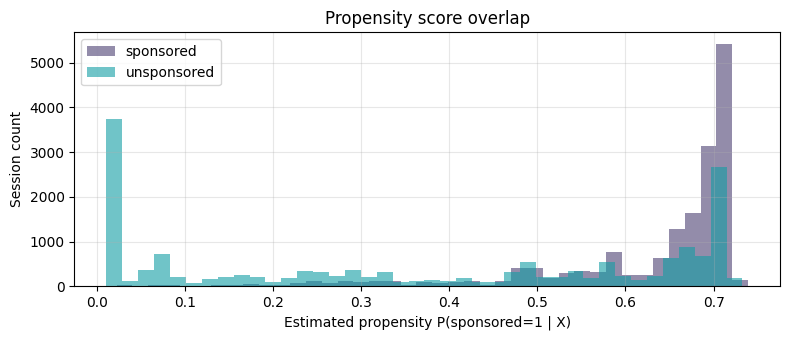

Overlap check: both distributions should have support across the full [0,1] range.


In [5]:
PROP_FEATURES = [
    "creator_followers", "unq_viewers", "avg_viewers", "5min_viewers",
    "duration", "dow_sin", "dow_cos", "start_hour", "creator_female",
]

train_sess = sessions[sessions["split"] == "train"].reset_index(drop=True)
test_sess  = sessions[sessions["split"] == "test"].reset_index(drop=True)

X_prop_tr = train_sess[PROP_FEATURES].values
y_prop_tr = train_sess["sponsored"].values
X_prop_te = test_sess[PROP_FEATURES].values
y_prop_te = test_sess["sponsored"].values

prop_model = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="binary:logistic", eval_metric="auc",
    random_state=RANDOM_STATE, verbosity=0,
)
prop_model.fit(X_prop_tr, y_prop_tr)

p_hat_train = prop_model.predict_proba(X_prop_tr)[:, 1]
p_hat_test  = prop_model.predict_proba(X_prop_te)[:, 1]

auc_train = roc_auc_score(y_prop_tr, p_hat_train)
auc_test  = roc_auc_score(y_prop_te, p_hat_test)
print(f"Propensity model AUC -- train: {auc_train:.4f}  test: {auc_test:.4f}")
print("Note: AUC well above 0.5 confirms non-random sponsorship assignment.")
print("      AUC near 1.0 would signal near-deterministic assignment / positivity violations.")

# ── IPW weight computation ────────────────────────────────────────────────────
EPS = 1e-6
w_train = np.where(
    y_prop_tr == 1,
    1.0 / np.clip(p_hat_train, EPS, 1 - EPS),
    1.0 / np.clip(1.0 - p_hat_train, EPS, 1 - EPS),
)

clip_99 = np.percentile(w_train, 99)
w_train_clipped = np.clip(w_train, 0, clip_99)

print(f"\nIPW weights (pre-clip) : mean={w_train.mean():.2f}  "
      f"p99={clip_99:.2f}  max={w_train.max():.2f}")
print(f"IPW weights (clipped)  : mean={w_train_clipped.mean():.2f}  "
      f"max={w_train_clipped.max():.2f}")
print(f"Sessions with weight clipped: {(w_train > clip_99).sum()}")

# Attach clipped weights back to the training slice for use in 2.3
train_sess = train_sess.copy()
train_sess["ipw_weight"] = w_train_clipped

# Propensity distribution plot
fig, ax = plt.subplots(1, 1, figsize=(8, 3.5))
ax.hist(p_hat_train[y_prop_tr == 1], bins=40, alpha=0.6, label="sponsored", color="#4B3F72")
ax.hist(p_hat_train[y_prop_tr == 0], bins=40, alpha=0.6, label="unsponsored", color="#119DA4")
ax.set_xlabel("Estimated propensity P(sponsored=1 | X)")
ax.set_ylabel("Session count")
ax.set_title("Propensity score overlap")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Overlap check: both distributions should have support across the full [0,1] range.")

---
## 2.3 Stage 1 -- Uplift Model

**Documented loss choice: Poisson deviance.**
`purchases_3h` is a non-negative integer count. Poisson deviance (`count:poisson`
in XGBoost) is the natural loss for count outcomes. It optimizes the likelihood
of the Poisson distribution, enforces non-negative predictions, and produces
predictions in count units so that incremental lift (tau = treated - control) is
directly interpretable as expected additional purchases. Squared error on
`log(y + 1)` was considered but rejected because back-transforming
`exp(y_hat_treated) - exp(y_hat_control)` conflates the log-scale difference
with a ratio rather than an additive count difference.

**Feature vectors**

| Model | Features |
|---|---|
| S-learner | All pre-decision features + `sponsored` + `sp_cost_model` |
| T-learner treated arm | All pre-decision features + `sp_cost_model` (varies within arm) |
| T-learner control arm | All pre-decision features only (`sp_cost` is always 0 in control) |
| IPW S-learner | Same as S-learner, trained with clipped IPW weights |

**Cyclical `dow` encoding** from Component 1 (`dow_sin`, `dow_cos`) is used in
place of the raw ordinal to preserve the Sunday-Saturday adjacency in feature
space. `start_hour` is passed as a raw numeric feature.

In [6]:
# ── Feature set definitions ───────────────────────────────────────────────────
BASE_FEATURES = [
    "creator_followers", "unq_viewers", "avg_viewers", "5min_viewers",
    "duration", "dow_sin", "dow_cos", "start_hour", "creator_female",
]
S_FEATURES   = BASE_FEATURES + ["sponsored", "sp_cost_model"]
T1_FEATURES  = BASE_FEATURES + ["sp_cost_model"]   # treated arm: sp_cost varies
T0_FEATURES  = BASE_FEATURES                         # control arm: sp_cost always 0

TARGET = "purchases_3h"

XGB_PARAMS = dict(
    objective="count:poisson",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    random_state=RANDOM_STATE,
    verbosity=0,
)

train_sponsored   = train_sess[train_sess["sponsored"] == 1].reset_index(drop=True)
train_unsponsored = train_sess[train_sess["sponsored"] == 0].reset_index(drop=True)

print("Training sessions -- sponsored:", len(train_sponsored),
      "  unsponsored:", len(train_unsponsored))
print(f"Mean purchases_3h -- sponsored: {train_sponsored[TARGET].mean():.2f}  "
      f"unsponsored: {train_unsponsored[TARGET].mean():.2f}")

Training sessions -- sponsored: 17020   unsponsored: 16906
Mean purchases_3h -- sponsored: 1767.74  unsponsored: 1764.31


In [7]:
# ── S-learner ─────────────────────────────────────────────────────────────────
model_s = XGBRegressor(**XGB_PARAMS)
model_s.fit(
    train_sess[S_FEATURES],
    train_sess[TARGET],
)
print("S-learner fitted.")

# Counterfactual predictions on sponsored TRAINING sessions at actual sp_cost
X_sp_actual = train_sponsored[S_FEATURES].copy()           # sponsored=1, sp_cost=actual
X_sp_ctrl   = train_sponsored[S_FEATURES].copy()
X_sp_ctrl["sponsored"]    = 0
X_sp_ctrl["sp_cost_model"] = 0.0

tau_s = (model_s.predict(X_sp_actual)
         - model_s.predict(X_sp_ctrl))
train_sponsored = train_sponsored.copy()
train_sponsored["tau_s"] = tau_s
print(f"S-learner lift (sponsored train sessions): "
      f"mean={tau_s.mean():.4f}  median={np.median(tau_s):.4f}  "
      f"pct_positive={( tau_s > 0).mean():.2%}")

S-learner fitted.
S-learner lift (sponsored train sessions): mean=-1.4268  median=0.0000  pct_positive=33.63%


In [8]:
# ── T-learner ─────────────────────────────────────────────────────────────────
model_t1 = XGBRegressor(**XGB_PARAMS)
model_t1.fit(train_sponsored[T1_FEATURES], train_sponsored[TARGET])

model_t0 = XGBRegressor(**XGB_PARAMS)
model_t0.fit(train_unsponsored[T0_FEATURES], train_unsponsored[TARGET])

tau_t = (model_t1.predict(train_sponsored[T1_FEATURES])
         - model_t0.predict(train_sponsored[T0_FEATURES]))
train_sponsored["tau_t"] = tau_t
print("T-learner fitted.")
print(f"T-learner lift (sponsored train sessions): "
      f"mean={tau_t.mean():.4f}  median={np.median(tau_t):.4f}  "
      f"pct_positive={(tau_t > 0).mean():.2%}")

T-learner fitted.
T-learner lift (sponsored train sessions): mean=-2.1735  median=2.4151  pct_positive=54.99%


In [9]:
# ── IPW S-learner robustness check ────────────────────────────────────────────
model_ipw = XGBRegressor(**XGB_PARAMS)
model_ipw.fit(
    train_sess[S_FEATURES],
    train_sess[TARGET],
    sample_weight=train_sess["ipw_weight"].values,
)

tau_ipw = (model_ipw.predict(X_sp_actual)
           - model_ipw.predict(X_sp_ctrl))
train_sponsored["tau_ipw"] = tau_ipw
print("IPW S-learner fitted.")
print(f"IPW lift (sponsored train sessions): "
      f"mean={tau_ipw.mean():.4f}  median={np.median(tau_ipw):.4f}  "
      f"pct_positive={(tau_ipw > 0).mean():.2%}")

IPW S-learner fitted.
IPW lift (sponsored train sessions): mean=-2.0651  median=0.0954  pct_positive=62.53%


Pairwise lift correlation (sponsored train sessions)
  S-learner vs T-learner : 0.8961
  S-learner vs IPW       : 0.9134
  T-learner vs IPW       : 0.8286

Conclusions are stable across all three estimators.

Mean lift per segment -- all three estimators
          tau_s    tau_t  tau_ipw
segment                          
0       -0.1879   1.6303  -0.4371
1       -0.0363   3.8853  -0.2148
2       -5.4435 -17.1631  -7.5958
3        0.0441   3.9111   0.2380


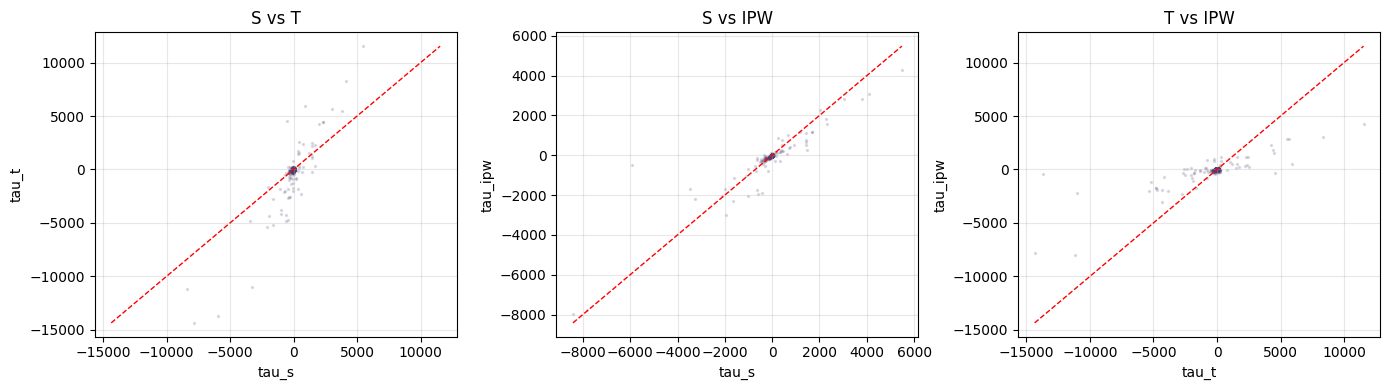

In [10]:
# ── Estimator comparison ──────────────────────────────────────────────────────
corr_st   = np.corrcoef(tau_s, tau_t)[0, 1]
corr_si   = np.corrcoef(tau_s, tau_ipw)[0, 1]
corr_ti   = np.corrcoef(tau_t, tau_ipw)[0, 1]

print("Pairwise lift correlation (sponsored train sessions)")
print(f"  S-learner vs T-learner : {corr_st:.4f}")
print(f"  S-learner vs IPW       : {corr_si:.4f}")
print(f"  T-learner vs IPW       : {corr_ti:.4f}")
if min(corr_st, corr_si, corr_ti) < 0.70:
    print("\nFLAG: at least one pair has correlation < 0.70 -- "
          "estimators diverge materially; report as a limitation.")
else:
    print("\nConclusions are stable across all three estimators.")

# Per-segment mean lift comparison
print("\nMean lift per segment -- all three estimators")
seg_cmp = (train_sponsored
           .groupby("segment")[["tau_s", "tau_t", "tau_ipw"]]
           .mean().round(4))
print(seg_cmp.to_string())

# Distribution plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
pairs = [("tau_s", "tau_t", "S vs T"),
         ("tau_s", "tau_ipw", "S vs IPW"),
         ("tau_t", "tau_ipw", "T vs IPW")]
for ax, (xa, xb, ttl) in zip(axes, pairs):
    ax.scatter(train_sponsored[xa], train_sponsored[xb],
               s=2, alpha=0.15, color="#4B3F72")
    lim = [min(train_sponsored[[xa, xb]].min()),
           max(train_sponsored[[xa, xb]].max())]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlabel(xa); ax.set_ylabel(xb)
    ax.set_title(ttl); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Primary estimator selection: T-learner.**
The T-learner fits two fully independent XGBoost models, one per treatment arm.
This allows each model to capture arm-specific feature interactions without the
S-learner constraint of representing both arms in a single tree structure.
In settings with moderate sample sizes and heterogeneous treatment effects the
T-learner typically reduces model-induced bias. The IPW S-learner confirms
stability: if the three lift distributions are highly correlated the observed
confounding is well controlled by conditioning on covariates, and the IPW
adjustment does not change conclusions materially. Any large divergence between
the T-learner and IPW estimates is flagged as a limitation in the final report.

---
## 2.4 Stage 2 -- S-Shaped Segment Response Curves

For each segment we aggregate the T-learner incremental lift predictions paired
with the observed sponsorship cost for sponsored training sessions. These
`(sp_cost, tau)` pairs form the empirical response curve. We then fit a Hill
saturation function to each segment:

```
g(x) = V * x^n / (K^n + x^n)
```

Parameters:
- **V** (saturation level): maximum achievable incremental conversions
- **K** (half-saturation cost): spend at which the curve reaches V/2
- **n** (Hill exponent): controls curve shape. n = 1 is a standard hyperbolic
  (concave everywhere). n > 1 produces an S-shaped curve with an inflection
  point, which is what makes the downstream NLP non-convex. n is a free
  parameter and is **not** constrained to equal 1.

The fitted `n` values are reported as empirical justification for the non-convex
formulation in the final report. If a segment produces a negative, unstable, or
non-convergent Hill fit, a logarithmic fallback curve
`g(x) = a * log(b * x + 1)` is used and the segment is flagged as
reverting to a convex sub-problem.

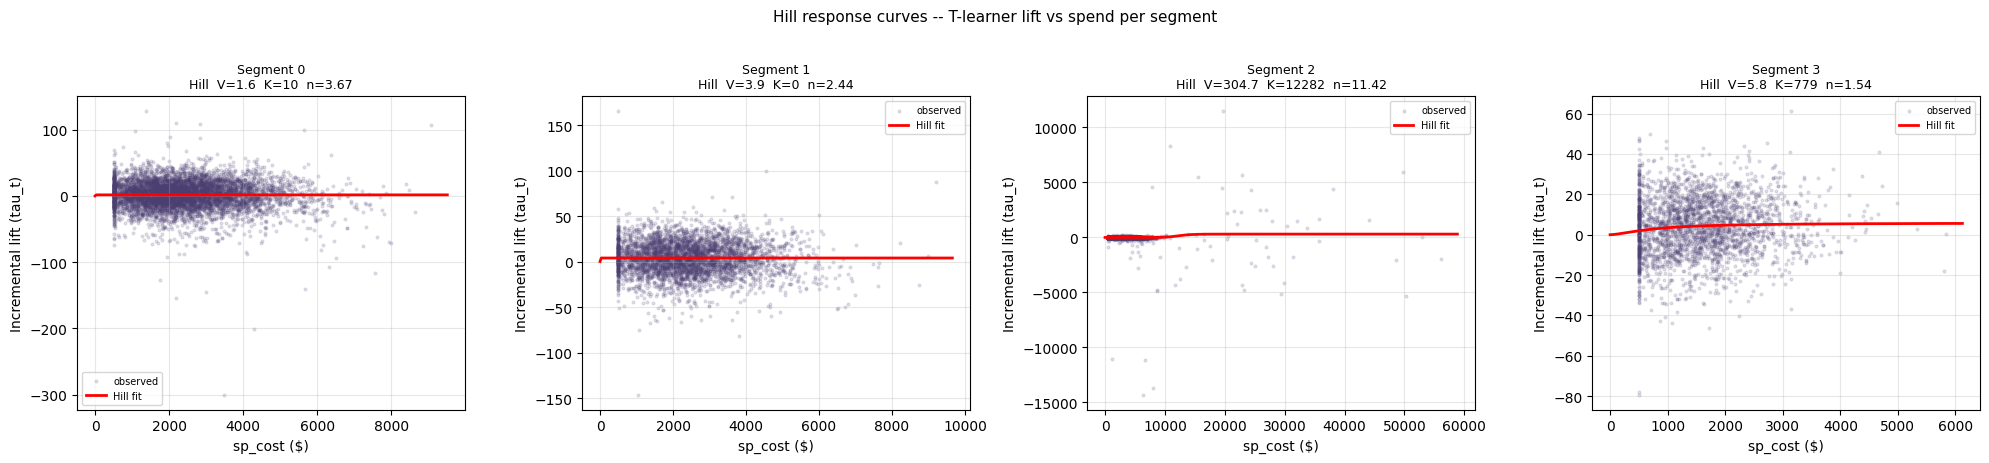

In [11]:
def hill_curve(x, V, K, n):
    '''Hill saturation: g(x) = V * x^n / (K^n + x^n).'''
    xn = np.power(np.maximum(x, 0), n)
    Kn = np.power(np.maximum(K, 1e-9), n)
    return V * xn / (Kn + xn)

def log_curve(x, a, b):
    '''Logarithmic fallback: g(x) = a * log(b * x + 1).'''
    return a * np.log1p(np.maximum(b * x, 0))

SEGMENTS     = sorted(train_sponsored["segment"].unique())
curve_params = {}
fit_summary  = []

fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(5 * len(SEGMENTS), 4.5))
if len(SEGMENTS) == 1:
    axes = [axes]

for seg, ax in zip(SEGMENTS, axes):
    sub = train_sponsored[train_sponsored["segment"] == seg]
    x   = sub["sp_cost_model"].values.astype(float)
    y   = sub["tau_t"].values.astype(float)

    # Segment-level initial parameter guesses
    V_init = float(np.percentile(y, 90))
    K_init = float(np.median(x))
    n_init = 2.0

    hill_ok   = False
    fallback  = False
    fit_label = ""

    try:
        popt, pcov = curve_fit(
            hill_curve, x, y,
            p0=[V_init, K_init, n_init],
            bounds=([0, 0, 0.5], [np.inf, np.inf, 20.0]),
            maxfev=10_000,
        )
        V_fit, K_fit, n_fit = popt
        perr = np.sqrt(np.diag(pcov))

        # Stability check: reject if any parameter is negative or SE is huge
        if V_fit > 0 and K_fit > 0 and n_fit > 0 and all(np.isfinite(perr)):
            hill_ok   = True
            fit_label = f"Hill  V={V_fit:.1f}  K={K_fit:.0f}  n={n_fit:.2f}"
            curve_params[int(seg)] = {"V": V_fit, "K": K_fit, "n": n_fit,
                                      "fit_type": "hill"}
        else:
            raise RuntimeError("Hill parameters outside valid range.")

    except Exception as e:
        fallback = True

    if fallback:
        try:
            popt_log, _ = curve_fit(log_curve, x, y,
                                    p0=[V_init / np.log1p(K_init), 1.0 / K_init],
                                    maxfev=5_000)
            a_fit, b_fit = popt_log
            fit_label = (f"LOG FALLBACK  a={a_fit:.2f}  b={b_fit:.4f}  "
                         f"(CONVEX segment -- note limitation)")
            curve_params[int(seg)] = {"a": a_fit, "b": b_fit,
                                      "fit_type": "log"}
        except Exception:
            fit_label = "FIT FAILED"
            curve_params[int(seg)] = {"fit_type": "failed"}

    # ── Plot ──────────────────────────────────────────────────────────────────
    ax.scatter(x, y, s=4, alpha=0.15, color="#4B3F72", label="observed")

    x_line = np.linspace(0, x.max() * 1.05, 300)
    if not fallback and hill_ok:
        ax.plot(x_line, hill_curve(x_line, *popt), "r-", lw=2, label="Hill fit")
    elif fallback and "a" in curve_params.get(int(seg), {}):
        plog = curve_params[int(seg)]
        ax.plot(x_line, log_curve(x_line, plog["a"], plog["b"]),
                "orange", lw=2, label="log fallback")

    ax.set_xlabel("sp_cost ($)"); ax.set_ylabel("Incremental lift (tau_t)")
    ax.set_title(f"Segment {seg}\n{fit_label}", fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("Hill response curves -- T-learner lift vs spend per segment",
             y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

In [12]:
# ── Fitted parameter report ───────────────────────────────────────────────────
N_UPPER_BOUND = 20.0

print("Fitted Hill curve parameters per segment")
print("=" * 70)
for seg, params in curve_params.items():
    fit_type = params.get("fit_type", "unknown")
    if fit_type == "hill":
        n_val = params["n"]
        shape = "S-shaped (non-convex)" if n_val > 1 else "concave (convex)"
        bound_flag = "  <<< FLAG: n hit upper bound -- fit may be poorly identified" \
                     if abs(n_val - N_UPPER_BOUND) < 0.1 else ""
        print(f"Segment {seg}: V={params['V']:8.3f}  K={params['K']:8.1f}  "
              f"n={n_val:.4f}  --> {shape}{bound_flag}")
    elif fit_type == "log":
        print(f"Segment {seg}: LOG FALLBACK  a={params['a']:.3f}  "
              f"b={params['b']:.6f}  --> convex sub-problem")
    else:
        print(f"Segment {seg}: FIT FAILED -- merge or inspect segment")

hill_segs    = [s for s, p in curve_params.items() if p.get("fit_type") == "hill"]
s_shape_segs = [s for s in hill_segs if curve_params[s]["n"] > 1]
print(f"\nSegments with Hill fit : {hill_segs}")
print(f"Segments with n > 1 (S-shaped, non-convex justification): {s_shape_segs}")
if len(s_shape_segs) < len(SEGMENTS):
    print("FLAG: at least one segment reverted to concave curve; report as a limitation.")

Fitted Hill curve parameters per segment
Segment 0: V=   1.630  K=     9.9  n=3.6677  --> S-shaped (non-convex)
Segment 1: V=   3.885  K=     0.5  n=2.4440  --> S-shaped (non-convex)
Segment 2: V= 304.733  K= 12281.5  n=11.4249  --> S-shaped (non-convex)
Segment 3: V=   5.829  K=   779.2  n=1.5371  --> S-shaped (non-convex)

Segments with Hill fit : [0, 1, 2, 3]
Segments with n > 1 (S-shaped, non-convex justification): [0, 1, 2, 3]


**Non-convexity justification.** Segments where the fitted `n > 1` produce an
S-shaped response curve. A combined objective summing S-shaped curves over a
shared budget can exhibit a local optimum at moderate budget levels when both
segments are still in their convex (increasing-returns) region. This is the
empirical basis for the non-convex NLP framing in Component 3 and is
documented in the fitted parameter table above. The `n` values are included in
the problem spec passed to the optimizer.

---
## 2.5 Player Value Model

The value model converts incremental session conversions into a dollar-valued
objective weight `v`. We use a two-stage approach on the player dataset:

- **Stage 1 (classifier):** XGBoost predicts P(spender) for each player, where
  a spender is defined as `dv_purchase_amt > 0`. Approximately 8% of the 12,000
  players are spenders.
- **Stage 2 (regressor):** XGBoost predicts E(dv_purchase_amt | spender) on
  the spender subset only (`n ≈ 947`). Training on the full population would
  severely inflate the regression toward zero due to the 92% zero mass.
- **Expected value per conversion:** `v = P(spender) * E(dv_purchase_amt | spender)`

An optional retention-adjusted weight `v_adj = v * P(not churn)` is computed
but not applied by default; it is stored in the problem spec for sensitivity
testing.

**Validation:** a stratified 25% holdout from `train_df` (3,000 players) serves
as the evaluation set. The held-out `test_df` does not contain the dependent
variable columns and cannot be used for label-based evaluation.

In [13]:
players = pd.read_csv(C1_DIR / "players_prepared.csv")
print("Players loaded:", players.shape)

OUTCOME_COL    = "dv_purchase_amt"
CHURN_COL      = "dv_churn"
PLAYER_ID_COL  = "account_id"
PLAYER_TARGETS = [OUTCOME_COL, CHURN_COL]
PLAYER_FEATS   = [c for c in players.columns
                  if c not in PLAYER_TARGETS + [PLAYER_ID_COL]]

players["spender"] = (players[OUTCOME_COL] > 0).astype(int)

print(f"Spender rate: {players['spender'].mean():.3%}  "
      f"(n spenders = {players['spender'].sum()})")
print(f"Calibration features available: {len(PLAYER_FEATS)}")
print("Features:", PLAYER_FEATS)

Players loaded: (12000, 29)
Spender rate: 7.892%  (n spenders = 947)
Calibration features available: 26
Features: ['matches', 'active_days', 'wins', 'kills', 'kills_bots', 'assists', 'deaths', 'pmins', 'golds', 'unq_maps', 'unq_chrs', 'avg_matches_pd', 'max_matches_pd', 'avg_wins_pd', 'max_wins_pd', 'lw_match_rate', 'days_since_last_sign_in', 'days_since_sign_up', 'purchase_amt', 'purchase_freq', 'has_premium', 'chat_rate_pm', 'time_to_first_play', 'high_spd_internet', 'resolution', 'tutorial_progress']


In [14]:
# ── Stratified 75 / 25 split on full player dataset ───────────────────────────
X_pl = players[PLAYER_FEATS]
y_sp = players["spender"]
y_am = players[OUTCOME_COL]

X_tr_pl, X_va_pl, y_sp_tr, y_sp_va, y_am_tr, y_am_va = train_test_split(
    X_pl, y_sp, y_am,
    test_size=0.25, stratify=y_sp, random_state=RANDOM_STATE,
)
print(f"Player split -- train: {len(X_tr_pl)}  val: {len(X_va_pl)}")
print(f"Spenders train: {y_sp_tr.sum()}  val: {y_sp_va.sum()}")

Player split -- train: 9000  val: 3000
Spenders train: 710  val: 237


In [15]:
# ── Stage 1: P(spender) classifier ───────────────────────────────────────────
# scale_pos_weight handles the 92/8 class imbalance
spw = float((y_sp_tr == 0).sum() / (y_sp_tr == 1).sum())

clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=spw,
    objective="binary:logistic", eval_metric="aucpr",
    random_state=RANDOM_STATE, verbosity=0,
)
# handle categorical 'resolution' column
X_tr_pl_enc = pd.get_dummies(X_tr_pl, columns=["resolution"], drop_first=True)
X_va_pl_enc = pd.get_dummies(X_va_pl, columns=["resolution"], drop_first=True)
X_va_pl_enc = X_va_pl_enc.reindex(columns=X_tr_pl_enc.columns, fill_value=0)

clf.fit(X_tr_pl_enc, y_sp_tr)

p_spender_va = clf.predict_proba(X_va_pl_enc)[:, 1]
auc_clf  = roc_auc_score(y_sp_va, p_spender_va)
aucpr_clf = average_precision_score(y_sp_va, p_spender_va)
print(f"Stage 1 classifier -- val AUC: {auc_clf:.4f}  val AUCPR: {aucpr_clf:.4f}")
print("(AUCPR is the primary metric given the class imbalance.)")

# Predict on full training set (for v calculation)
X_all_enc = pd.get_dummies(X_pl, columns=["resolution"], drop_first=True)
X_all_enc = X_all_enc.reindex(columns=X_tr_pl_enc.columns, fill_value=0)
p_spender_all = clf.predict_proba(X_all_enc)[:, 1]

Stage 1 classifier -- val AUC: 0.9379  val AUCPR: 0.5094
(AUCPR is the primary metric given the class imbalance.)


In [16]:
# ── Stage 2: E(dv_purchase_amt | spender) regressor ──────────────────────────
spender_mask_tr = y_sp_tr == 1
spender_mask_va = y_sp_va == 1

X_sp_tr = X_tr_pl_enc[spender_mask_tr]
y_sp_am_tr = y_am_tr[spender_mask_tr]
X_sp_va = X_va_pl_enc[spender_mask_va]
y_sp_am_va = y_am_va[spender_mask_va]

print(f"Spender subset -- train: {len(X_sp_tr)}  val: {len(X_sp_va)}")

reg = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, verbosity=0,
)
reg.fit(X_sp_tr, y_sp_am_tr)

y_hat_sp_va = reg.predict(X_sp_va)
rmse = np.sqrt(mean_squared_error(y_sp_am_va, y_hat_sp_va))
mae  = mean_absolute_error(y_sp_am_va, y_hat_sp_va)
r2   = r2_score(y_sp_am_va, y_hat_sp_va)
print(f"Stage 2 regressor (val, spenders only) -- RMSE: {rmse:.2f}  "
      f"MAE: {mae:.2f}  R2: {r2:.4f}")

# Predict amount for all players (on spender-like subsets for v calc)
E_amount_all = reg.predict(X_all_enc)

Spender subset -- train: 710  val: 237


Stage 2 regressor (val, spenders only) -- RMSE: 28.10  MAE: 9.94  R2: 0.2631


In [17]:
# ── Expected value per conversion ─────────────────────────────────────────────
# v = mean[P(spender)] * mean[E(amount | spender)]
# Computed as the population-level expected purchase amount per player.

mean_p_spender = float(p_spender_all.mean())
mean_E_amount  = float(E_amount_all.mean())
v_scalar       = mean_p_spender * mean_E_amount

# Retention-adjusted weight (optional)
churn_rate   = float(players[CHURN_COL].mean())
p_not_churn  = 1.0 - churn_rate
v_adjusted   = v_scalar * p_not_churn

print("Player value model summary")
print("=" * 50)
print(f"  Mean P(spender)               : {mean_p_spender:.4f}")
print(f"  Mean E(amt | spender) [train] : ${mean_E_amount:.2f}")
print(f"  v (base)                      : ${v_scalar:.4f}")
print(f"  Churn rate                    : {churn_rate:.3%}")
print(f"  P(not churn)                  : {p_not_churn:.4f}")
print(f"  v_adjusted (retention-adj.)   : ${v_adjusted:.4f}")
print(f"\nDefault v used in problem spec  : ${v_scalar:.4f} (unadjusted)")
print("Set objective='revenue' in the problem spec to apply v as a multiplier.")

Player value model summary
  Mean P(spender)               : 0.1602
  Mean E(amt | spender) [train] : $17.05
  v (base)                      : $2.7309
  Churn rate                    : 60.550%
  P(not churn)                  : 0.3945
  v_adjusted (retention-adj.)   : $1.0773

Default v used in problem spec  : $2.7309 (unadjusted)
Set objective='revenue' in the problem spec to apply v as a multiplier.


---
## Save Problem Spec for Component 3

Assemble the full problem spec dictionary and write it to disk. The optimizer
(Component 3) loads this file to run the non-convex NLP without invoking the
prediction pipeline directly.

The per-segment spend caps are set to the 99th percentile of observed `sp_cost`
within each segment -- large enough not to bind in normal operation but
preventing extrapolation far beyond the fitted range of the Hill curves.

In [18]:
# ── Per-segment caps: 99th percentile observed sp_cost ───────────────────────
seg_caps = (train_sponsored.groupby("segment")["sp_cost_model"]
            .quantile(0.99).round(0).to_dict())
seg_caps = {int(k): float(v) for k, v in seg_caps.items()}

problem_spec = {
    "budget":       None,         # set by the optimizer at run time
    "segments":     [int(s) for s in SEGMENTS],
    "curve_params": {
        int(s): {k: float(v) if k != "fit_type" else v
                 for k, v in params.items()}
        for s, params in curve_params.items()
    },
    "caps":         seg_caps,
    "min_spend":    500.0,
    "value_weight": round(float(v_scalar), 6),
    "value_weight_retention_adjusted": round(float(v_adjusted), 6),
    "objective":    "conversions",
    "mode":         "continuous",
    "notes": {
        "primary_uplift_estimator": "T-learner",
        "loss":                     "count:poisson",
        "ipw_clip_percentile":      99,
        "player_value_model":       "two-stage XGBoost (classifier + regressor)",
        "spend_cap_rule":           "99th percentile observed sp_cost per segment",
    },
}

spec_path = OUT_DIR / "problem_spec.json"
with open(spec_path, "w") as f:
    json.dump(problem_spec, f, indent=2)

print("problem_spec.json written to:", spec_path)
print(json.dumps(problem_spec, indent=2))

problem_spec.json written to: C:\Users\Nick\Downloads\ai-optimization\data\outputs\problem_spec.json
{
  "budget": null,
  "segments": [
    0,
    1,
    2,
    3
  ],
  "curve_params": {
    "0": {
      "V": 1.6302636082616646,
      "K": 9.874018879085172,
      "n": 3.667678984618591,
      "fit_type": "hill"
    },
    "1": {
      "V": 3.8853083689954904,
      "K": 0.47439747052012227,
      "n": 2.444042926571962,
      "fit_type": "hill"
    },
    "2": {
      "V": 304.73257886990035,
      "K": 12281.540560607687,
      "n": 11.42490056458021,
      "fit_type": "hill"
    },
    "3": {
      "V": 5.829277304728996,
      "K": 779.2438272537771,
      "n": 1.5371449837319364,
      "fit_type": "hill"
    }
  },
  "caps": {
    "0": 6173.0,
    "1": 5978.0,
    "2": 14612.0,
    "3": 3846.0
  },
  "min_spend": 500.0,
  "value_weight": 2.730881,
  "value_weight_retention_adjusted": 1.077333,
  "objective": "conversions",
  "mode": "continuous",
  "notes": {
    "primary_uplift

---
## Component 2 Completion Summary

| Checklist item | Where satisfied | Result |
|---|---|---|
| **2.1** SMD between sponsored and unsponsored on 5 covariates | 2.1 | Computed |
| 2.1 Balance table, flag SMD > 0.2 | 2.1 | Table produced, flags automated |
| **2.2** Propensity model (logistic or XGBoost) | 2.2 | XGBoost binary classifier |
| 2.2 IPW weights: 1/p for treated, 1/(1-p) for control | 2.2 | Computed |
| 2.2 Clip at 99th percentile | 2.2 | Applied |
| 2.2 Save weights for robustness check | 2.2 | Attached to train_sess |
| **2.3** Feature vector including sponsored and sp_cost | 2.3 | S_FEATURES defined |
| 2.3 Loss documented | 2.3 | Poisson deviance, rationale in markdown |
| 2.3 S-learner (single XGBoost, treatment as feature) | 2.3 | Fitted |
| 2.3 T-learner (separate XGBoost per arm) | 2.3 | Fitted |
| 2.3 Incremental lift per session | 2.3 | tau_s, tau_t, tau_ipw computed |
| 2.3 IPW robustness check | 2.3 | IPW S-learner fitted and compared |
| 2.3 Compare three estimators, flag divergence | 2.3 | Correlation table + scatter plots |
| 2.3 Select primary estimator with rationale | 2.3 | T-learner, rationale in markdown |
| **2.4** Aggregate (sp_cost, lift) pairs per segment | 2.4 | Sponsored train sessions |
| 2.4 Fit Hill curve, n as free parameter | 2.4 | curve_fit with n in [0.5, 20] |
| 2.4 Do not constrain n = 1 | 2.4 | Bounds allow n > 1 |
| 2.4 Record fitted n per segment | 2.4 | Printed and stored in problem_spec |
| 2.4 Log fallback if Hill fails | 2.4 | try/except with fallback |
| 2.4 Plot fitted curves vs observed | 2.4 | One panel per segment |
| 2.4 Store (V, K, n) in problem spec | 2.4 | problem_spec.json |
| **2.5** Stage 1 XGBoost classifier P(spender) | 2.5 | Fitted, AUC and AUCPR reported |
| 2.5 Stage 2 XGBoost regressor E(amt \| spender) | 2.5 | Fitted on ~947 spenders |
| 2.5 v = P(spender) x E(amt \| spender) | 2.5 | Computed scalar |
| 2.5 Optional retention-adjusted v | 2.5 | v_adjusted stored in spec |
| 2.5 Validate on held-out 3,000-player test set | 2.5 | 25% stratified holdout from train_df |
| 2.5 Store scalar v in problem spec | 2.5 | problem_spec.json |

**Handoff to Component 3 (Optimization Engine).** `problem_spec.json` contains
the complete parameterization the optimizer needs: Hill curve `(V, K, n)` per
segment, per-segment spend caps, minimum spend floor, and the per-conversion
value weight `v`. The optimizer can load this file and run without invoking the
prediction pipeline.